## Concepts Covered
- leaky_relu: custom activation function

- MyGlorotInitializer: custom Glorot/Xavier initializer

- MyL1Regularizer: custom L1 regularizer

- MyPositiveWeights: custom weight constraint (non-negative weights)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers, regularizers, constraints

# Load Data

In [13]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Custom Leaky ReLU Activation

In [14]:
@tf.function
def leaky_relu(z, alpha=0.01):
    return tf.maximum(alpha * z, z)

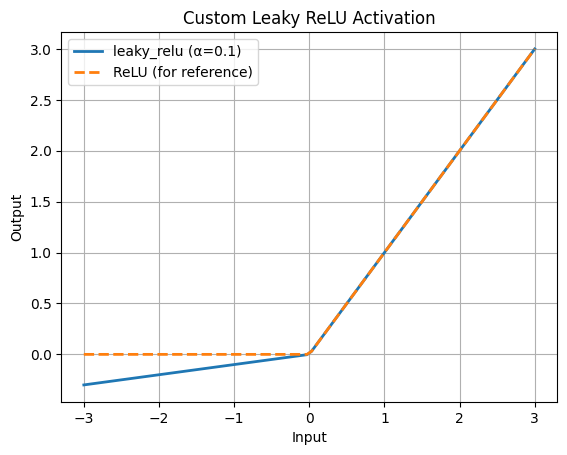

In [15]:
# 🎨 Plot leaky_relu vs ReLU
z = np.linspace(-3, 3, 100)
alpha = 0.1
plt.plot(z, np.maximum(alpha * z, z), label=f"leaky_relu (α={alpha})", linewidth=2)
plt.plot(z, np.maximum(0, z), '--', label="ReLU (for reference)", linewidth=2)
plt.title("Custom Leaky ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

# Custom Glorot Initializer

In [16]:
# Custom Glorot initializer
class MyGlorotInitializer(initializers.Initializer):
    def __call__(self, shape, dtype=None):
        fan_in, fan_out = shape[0], shape[1]
        limit = tf.sqrt(6.0 / (fan_in + fan_out))
        return tf.random.uniform(shape, -limit, limit, dtype=dtype)

# Custom L1 Regularizer

In [17]:
# Custom L1 regularizer
class MyL1Regularizer(regularizers.Regularizer):
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, x):
        return self.factor * tf.reduce_sum(tf.abs(x))

# Custom constraint: force positive weights

In [18]:
class MyPositiveWeights(constraints.Constraint):
    def __call__(self, w):
        return tf.nn.relu(w)

# Custom Dense layer

In [19]:
class CustomDense(layers.Layer):
    def __init__(self, units, alpha=0.01, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.alpha = alpha

    def build(self, input_shape):
        self.kernel = self.add_weight(
            shape=(int(input_shape[-1]), self.units),
            initializer=MyGlorotInitializer(),
            regularizer=MyL1Regularizer(0.001),
            constraint=MyPositiveWeights(),
            trainable=True,
            name="kernel"
        )
        self.bias = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

    def call(self, inputs):
        z = tf.matmul(inputs, self.kernel) + self.bias
        return leaky_relu(z, self.alpha)

# Build model

In [20]:
def build_custom_model():
    return keras.Sequential([
        keras.Input(shape=(28, 28, 1)),
        layers.Flatten(),
        CustomDense(128, alpha=0.1),
        CustomDense(64, alpha=0.1),
        layers.Dense(10, activation="softmax")
    ])

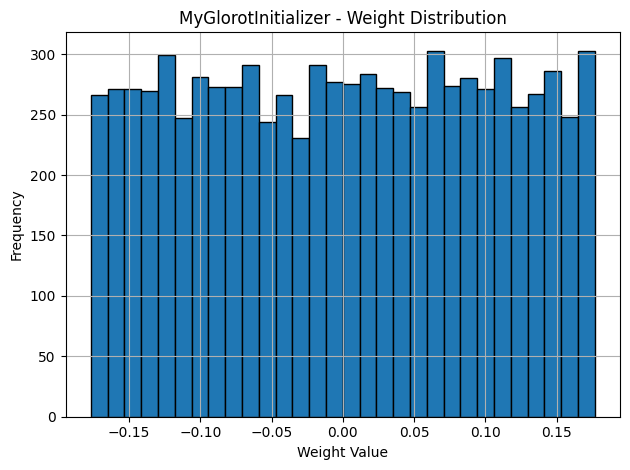

In [21]:
# 📊 Visualize Initial Weights from MyGlorotInitializer
temp_model = build_custom_model()
weights = temp_model.layers[2].kernel.numpy().flatten()
plt.hist(weights, bins=30, edgecolor='black')
plt.title("MyGlorotInitializer - Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Compile & train

In [22]:
# Train the model
model = build_custom_model()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=2)


Epoch 1/5
938/938 - 6s - 7ms/step - accuracy: 0.7276 - loss: 2.1877 - val_accuracy: 0.7821 - val_loss: 1.3025
Epoch 2/5
938/938 - 6s - 6ms/step - accuracy: 0.7980 - loss: 1.1824 - val_accuracy: 0.7892 - val_loss: 1.1195
Epoch 3/5
938/938 - 9s - 10ms/step - accuracy: 0.8049 - loss: 1.0265 - val_accuracy: 0.7901 - val_loss: 0.9928
Epoch 4/5
938/938 - 6s - 7ms/step - accuracy: 0.8100 - loss: 0.8936 - val_accuracy: 0.8004 - val_loss: 0.8581
Epoch 5/5
938/938 - 10s - 10ms/step - accuracy: 0.8122 - loss: 0.7981 - val_accuracy: 0.8045 - val_loss: 0.7837


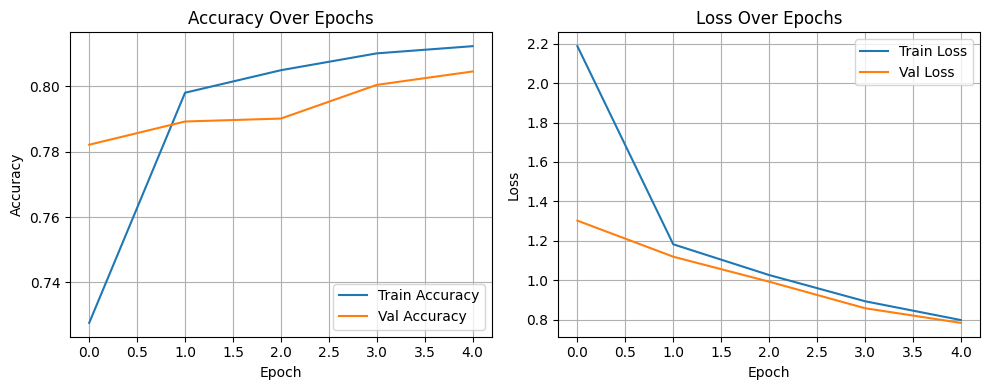

In [23]:
# 📈 Accuracy & Loss plots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()